In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(4, activation='softmax')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

for layer in model_resnet.layers[-30:]:
    layer.trainable = True

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet_finetune = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 747s 4s/step - accuracy: 0.6292 - loss: 0.9067 - val_accuracy: 0.4931 - val_loss: 1.3357
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 691s 4s/step - accuracy: 0.7835 - loss: 0.5486 - val_accuracy: 0.7325 - val_loss: 0.7436
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 730s 4s/step - accuracy: 0.8196 - loss: 0.4752 - val_accuracy: 0.7950 - val_loss: 0.6149
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.8403 - loss: 0.4126 - val_accuracy: 0.7981 - val_loss: 0.6363
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.8586 - loss: 0.3811 - val_accuracy: 0.7912 - val_loss: 0.6382


In [23]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(4, activation='softmax')(x)

model_mobile = models.Model(inputs=base_model.input, outputs=output)

model_mobile.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile = model_mobile.fit(train_data, validation_data=test_data, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 149s 828ms/step - accuracy: 0.7703 - loss: 0.5692 - val_accuracy: 0.7856 - val_loss: 0.7548
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 809ms/step - accuracy: 0.9006 - loss: 0.2704 - val_accuracy: 0.8500 - val_loss: 0.5672
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 143s 815ms/step - accuracy: 0.9228 - loss: 0.2096 - val_accuracy: 0.8394 - val_loss: 0.5921
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 801ms/step - accuracy: 0.9297 - loss: 0.1814 - val_accuracy: 0.8388 - val_loss: 0.5907
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 811ms/step - accuracy: 0.9386 - loss: 0.1635 - val_accuracy: 0.8438 - val_loss: 0.6425


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)   
output = layers.Dense(4, activation='softmax')(x)

model_dense = models.Model(inputs=base_model.input, outputs=output)

model_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dense = model_dense.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 586s 3s/step - accuracy: 0.6789 - loss: 0.8246 - val_accuracy: 0.8125 - val_loss: 0.6293
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.8601 - loss: 0.3730 - val_accuracy: 0.8219 - val_loss: 0.5408
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 532s 3s/step - accuracy: 0.8754 - loss: 0.3235 - val_accuracy: 0.8456 - val_loss: 0.5189
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.9006 - loss: 0.2895 - val_accuracy: 0.8431 - val_loss: 0.4929
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 567s 3s/step - accuracy: 0.9002 - loss: 0.2629 - val_accuracy: 0.8631 - val_loss: 0.4663


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(4, activation='softmax')(x)

model_inception = models.Model(inputs=base_model.input, outputs=output)

model_inception.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_inception = model_inception.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.6615 - loss: 0.9208 - val_accuracy: 0.8056 - val_loss: 0.5373
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8412 - loss: 0.4356 - val_accuracy: 0.8144 - val_loss: 0.5163
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.8525 - loss: 0.3722 - val_accuracy: 0.8494 - val_loss: 0.4258
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8757 - loss: 0.3344 - val_accuracy: 0.8456 - val_loss: 0.4200
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8790 - loss: 0.3142 - val_accuracy: 0.8594 - val_loss: 0.3759


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(4, activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1602s 9s/step - accuracy: 0.5577 - loss: 1.0739 - val_accuracy: 0.7613 - val_loss: 0.7407
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1591s 9s/step - accuracy: 0.7961 - loss: 0.5894 - val_accuracy: 0.7600 - val_loss: 0.7932
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1578s 9s/step - accuracy: 0.8292 - loss: 0.4877 - val_accuracy: 0.7694 - val_loss: 0.7158
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1575s 9s/step - accuracy: 0.8475 - loss: 0.4275 - val_accuracy: 0.7869 - val_loss: 0.7394
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1577s 9s/step - accuracy: 0.8483 - loss: 0.4118 - val_accuracy: 0.7925 - val_loss: 0.6655


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_resnet = model_resnet.predict(test_data)
pred_mobile = model_mobile.predict(test_data)
pred_dense = model_dense.predict(test_data)
pred_inception = model_inception.predict(test_data)

# VGG
pred_vgg = model_vgg.predict(test_data)


y_true = test_data.classes

y_pred = np.argmax(pred_resnet, axis=1)
print("RESNET\n", classification_report(y_true, y_pred))

y_pred = np.argmax(pred_mobile, axis=1)
print("MOBILENET\n", classification_report(y_true, y_pred))

y_pred = np.argmax(pred_dense, axis=1)
print("DENSENET\n", classification_report(y_true, y_pred))

y_pred = np.argmax(pred_inception, axis=1)
print("INCEPTION\n", classification_report(y_true, y_pred))

y_pred = np.argmax(pred_vgg, axis=1)
print("VGG\n", classification_report(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 564ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 344s 7s/step
RESNET
               precision    recall  f1-score   support

           0       0.80      0.67      0.73       400
           1       0.79      0.52      0.62       400
           2       0.73      0.99      0.84       400
           3       0.85      0.99      0.92       400

    accuracy                           0.79      1600
   macro avg       0.79      0.79      0.78      1600
weighted avg       0.79      0.79      0.78      1600

MOBILENET
               precision    recall  f1-score   support

           0       0.98      0.60      0.75       400
           1       0.75      0.81      0.78       400
           2       0.95      0.97      0.96       400
           3       0.77      1.00      0.87       400

    accuracy                           0.84      1600
   macro avg       

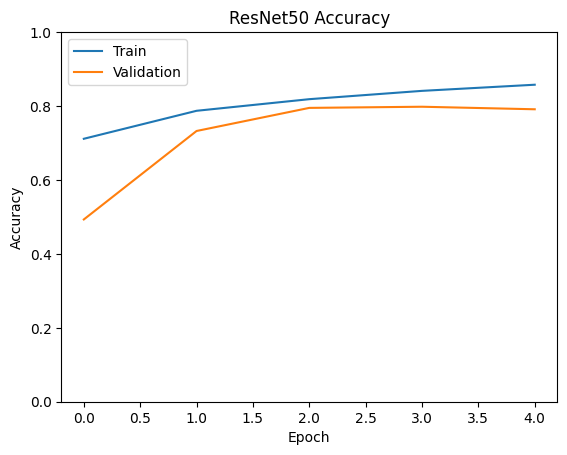

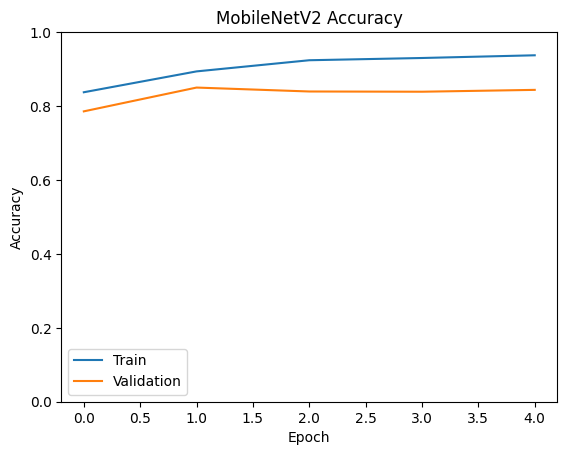

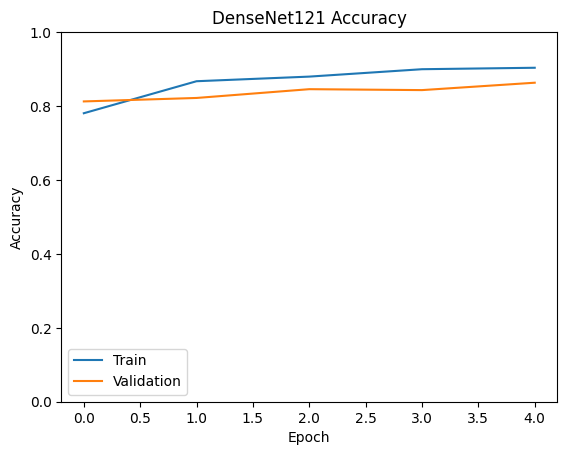

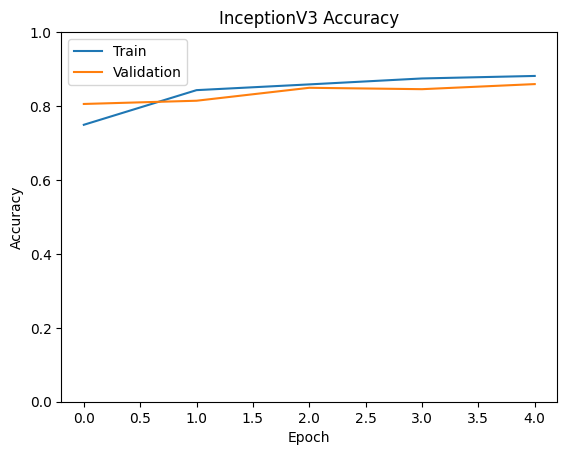

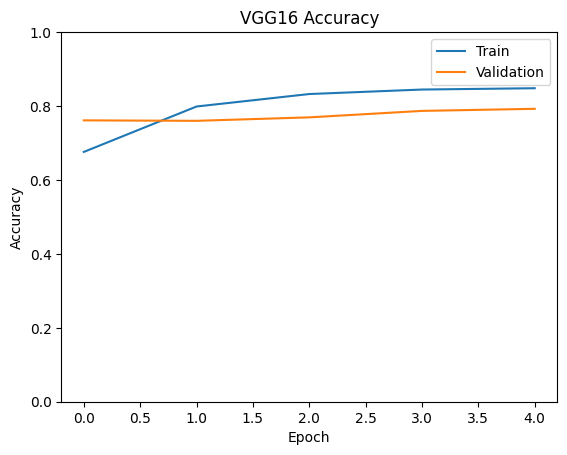

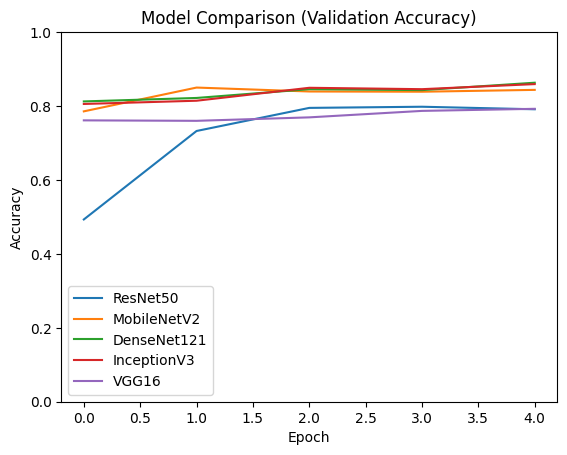

In [45]:
import matplotlib.pyplot as plt

# RESNET
plt.plot(history_resnet_finetune.history['accuracy'])
plt.plot(history_resnet_finetune.history['val_accuracy'])
plt.title('ResNet50 Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# MOBILENET
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# DENSENET
plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])
plt.title('DenseNet121 Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# INCEPTION
plt.plot(history_inception.history['accuracy'])
plt.plot(history_inception.history['val_accuracy'])
plt.title('InceptionV3 Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# VGG
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('VGG16 Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


plt.plot(history_resnet_finetune.history['val_accuracy'], label='ResNet50')
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2')
plt.plot(history_dense.history['val_accuracy'], label='DenseNet121')
plt.plot(history_inception.history['val_accuracy'], label='InceptionV3')
plt.plot(history_vgg.history['val_accuracy'], label='VGG16')

plt.legend()
plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()